In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import GridSearchCV


In [61]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
test['Survived'] = None # Ajout d'une colonne 'Survived' avec en valeur None. Nécessaire pour la fusion des jeux de données
full = pd.concat([train, test], sort=False)

# Extraction titre
full['Title'] = full['Name'].str.extract(r',\s*([^\.]*)\s*\.', expand=False).str.strip()

# Remplissage des âges manquants par médiane par groupe
age_medians = full.groupby(['Title', 'Pclass'])['Age'].median()
def impute_age(row):
    if pd.isnull(row['Age']):
        group_median = age_medians.get((row['Title'], row['Pclass']), np.nan)
        if pd.isnull(group_median):
            return full['Age'].median()
        return group_median
    return row['Age']
full['Age'] = full.apply(impute_age, axis=1)

# Encodage des variables catégorielles
le = LabelEncoder()
full['Sex'] = le.fit_transform(full['Sex'])
full['Title'] = le.fit_transform(full['Title'])
full['Embarked'] = full['Embarked'].fillna(full['Embarked'].mode()[0]) # Remplacement des valeurs manquants avec la valeur la plus fréquente
full['Embarked'] = le.fit_transform(full['Embarked']) # Encodage des valeurs (str) en valeurs numériques (int)

# Remplissage de 'Fare'
full['Fare'] = full['Fare'].fillna(full['Fare'].median())

# Suppression des colonnes inutiles
full.drop(columns=['Cabin', 'Ticket', 'Name', 'Embarked'], inplace=True)

# Création d'une variable 'Accompagnied' => Si un passager voyage avec au moins une personne = 1 sinon = 0
full['Accompagnied'] = ((full['SibSp'] + full['Parch']) > 0).astype(int)

# Suppression des variable 'SibSp' et 'Parch' 
full.drop(['SibSp', 'Parch'], axis=1, inplace=True)




In [62]:
train_data = full[full['Survived'].notnull()].copy()

X = train_data.drop('Survived', axis=1)
y = train_data['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

model = SVC(kernel='rbf', C=1, gamma='scale')

model.fit(X_train_scaler, y_train)

y_pred = model.predict(X_test_scaler)

print('Accuracy : ', accuracy_score(y_test, y_pred))
print('Rapport de classificatiin : ', classification_report(y_test, y_pred))



Accuracy :  0.8100558659217877
Rapport de classificatiin :                precision    recall  f1-score   support

           0       0.80      0.92      0.86       111
           1       0.83      0.63      0.72        68

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



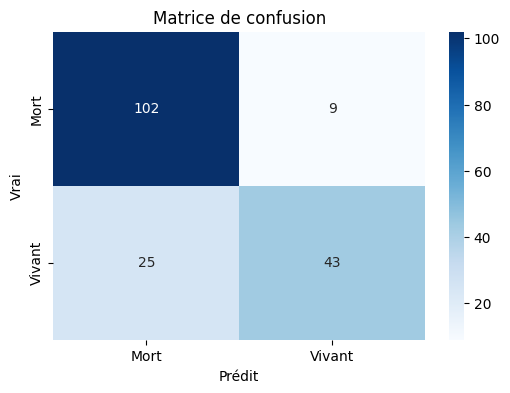

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Mort', 'Vivant'],
            yticklabels=['Mort', 'Vivant'])
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title("Matrice de confusion")
plt.show()

/tmp/ipykernel_44017/424168157.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=comparaison,


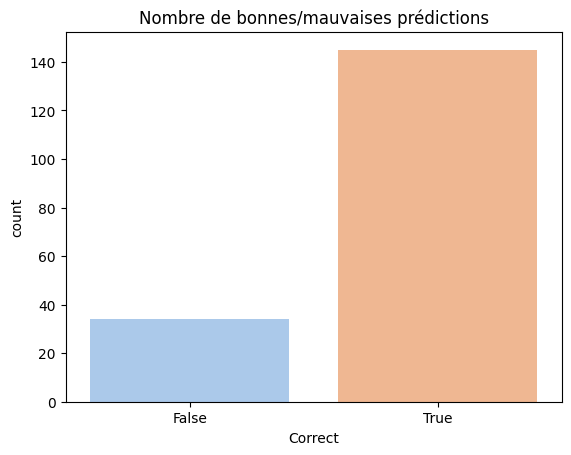

In [64]:
comparaison = pd.DataFrame({'Réel': y_test, 'Prédit': y_pred})
comparaison['Correct'] = comparaison['Réel'] == comparaison['Prédit']

sns.countplot(data=comparaison,
              x='Correct',
              palette='pastel')
plt.title('Nombre de bonnes/mauvaises prédictions')
plt.show()

In [66]:
param_grid ={
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']   
}


svc = SVC()
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train_scaler, y_train)

print('Meilleurs hyperparamètres : ', grid_search.best_params_)
print('Meilleure précision : ', grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs hyperparamètres :  {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Meilleure précision :  0.8005023145868216


In [67]:
y_pred = best_model.predict(X_test_scaler)

print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Rapport de classification : ", classification_report(y_test, y_pred))


Accuracy :  0.7988826815642458
Rapport de classification :                precision    recall  f1-score   support

           0       0.81      0.88      0.84       111
           1       0.78      0.66      0.71        68

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



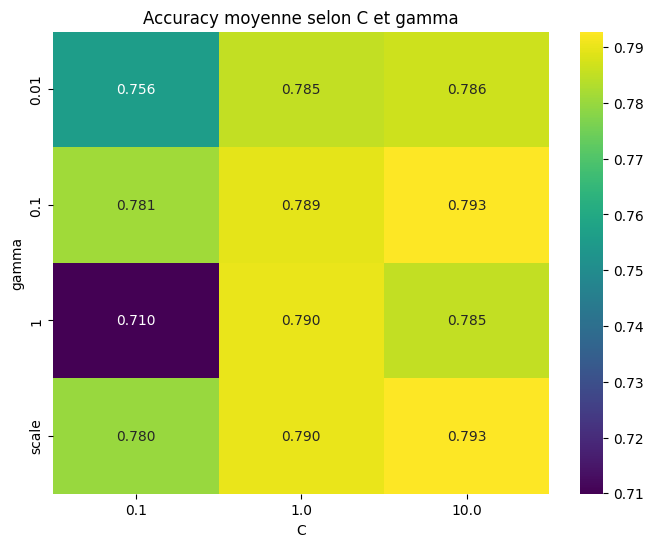

In [69]:
resultats = pd.DataFrame(grid_search.cv_results_)
pivot_table = resultats.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True,
            fmt='.3f', cmap='viridis')
plt.title("Accuracy moyenne selon C et gamma")
plt.xlabel('C')
plt.ylabel('gamma')
plt.show()